   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 3.3 MB/s eta 0:00:00


/tmp/ipykernel_2115/3796538050.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers + [benchmark], start=start_date, end=end_date)['Close']
[*********************100%***********************]  6 of 6 completed


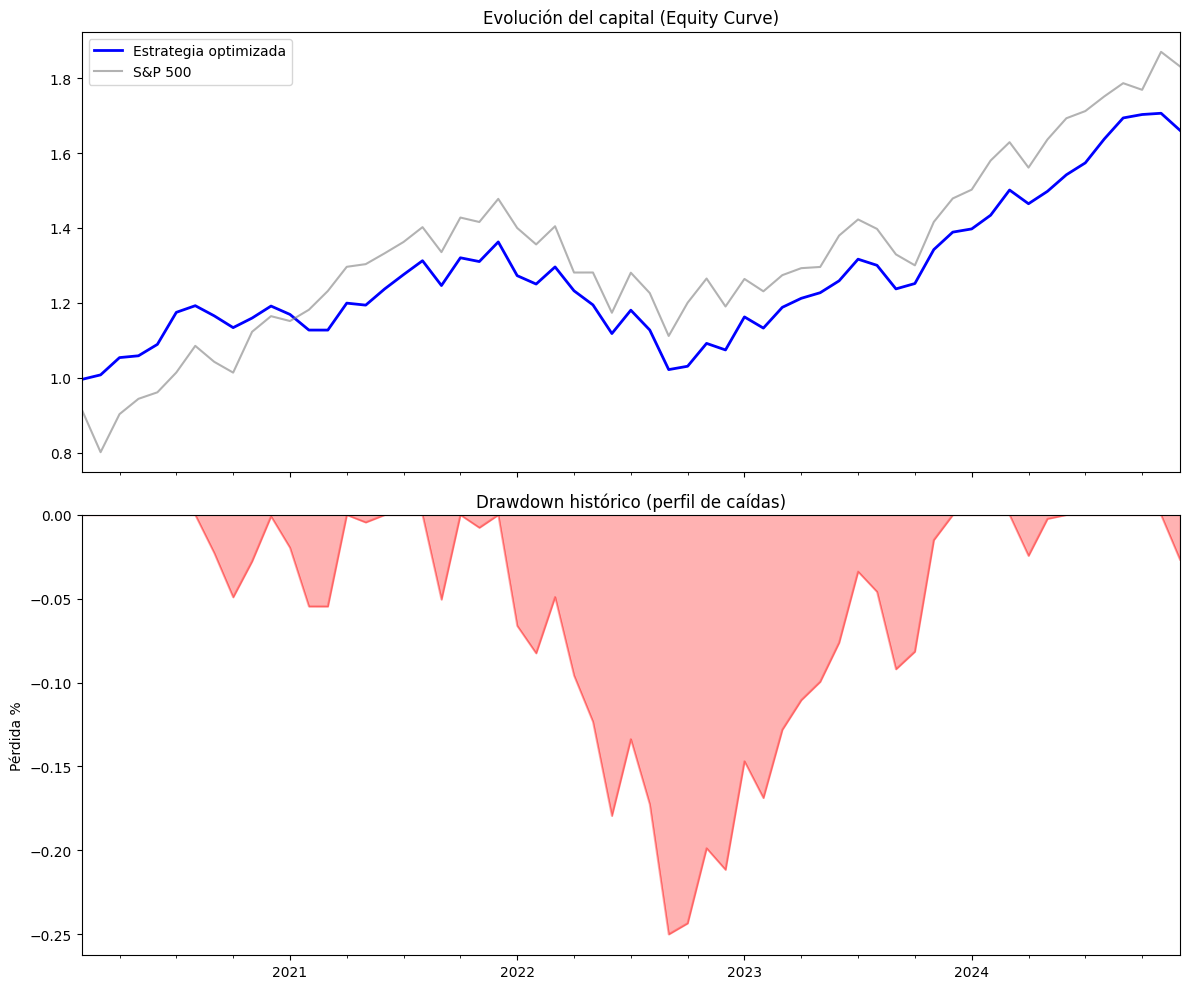


Métrica              | Estrategia   | Benchmark
--------------------------------------------------
CAGR (Anual)         |      10.87% | 13.09%
Volatilidad          |      13.32% | 18.32%
Ratio Sharpe         |        0.59 | 0.55
Ratio Sortino        |        0.97 | 0.91
Max Drawdown         |     -25.02% | -24.77%
Ratio Calmar         |        0.43 | 0.53


In [1]:
#PROYECTO: Systematic_Trading_Strategies
#Elaborado por: Ricardo Alexis Sifuentes Zevallos
#Objetivo: Backtesting de una estrategia de asset allocation optimizada (Max Sharpe) con rebalanceo mensual.

!pip install -q PyPortfolioOpt yfinance
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, risk_models, expected_returns

#1. DATOS (usamos ETFs sugeridos para Asset Management)
tickers = ['SPY', 'QQQ', 'GLD', 'TLT', 'VNQ']
benchmark = '^GSPC'
start_date = '2019-01-01'
end_date = '2024-12-31'

data = yf.download(tickers + [benchmark], start=start_date, end=end_date)['Close']

prices = data[tickers].dropna()
bench_prices = data[benchmark].dropna()

#2. MOTOR DE BACKTEST CON REBALANCEO MENSUAL
monthly_dates = prices.resample('ME').last().index
returns_daily = prices.pct_change().dropna()
portfolio_monthly_returns = []

#Ventana rodante de 12 meses para optimizar
for i in range(12, len(monthly_dates) - 1):
    start_train = monthly_dates[i-12]
    end_train = monthly_dates[i]

    #Optimización: Max Sharpe Ratio
    train_prices = prices.loc[start_train:end_train]
    mu = expected_returns.mean_historical_return(train_prices)
    S = risk_models.sample_cov(train_prices)

    try:
        ef = EfficientFrontier(mu, S)
        ef.add_constraint(lambda w: w <= 0.40) #límite de concentración
        weights = ef.max_sharpe(risk_free_rate=0.03)
        clean_weights = np.array([weights[t] for t in tickers])
    except:
        clean_weights = np.array([1.0/len(tickers)] * len(tickers))

    #Aplicación Out-of-Sample en el mes siguiente
    next_start = monthly_dates[i]
    next_end = monthly_dates[i+1]
    daily_returns_month = returns_daily.loc[next_start:next_end]

    #Retorno compuesto del mes
    daily_port_returns = daily_returns_month @ clean_weights
    monthly_compounded_return = (1 + daily_port_returns).prod() - 1

    portfolio_monthly_returns.append(pd.Series(monthly_compounded_return, index=[next_end]))

#Resultados
strat_ret = pd.concat(portfolio_monthly_returns)
bench_ret = bench_prices.resample('ME').last().pct_change().loc[strat_ret.index]

#3. MÉTRICAS DE ASSET MANAGEMENT
def get_advanced_metrics(returns):
    cum_ret = (1 + returns).cumprod()
    total_ret = cum_ret.iloc[-1] - 1

    #CAGR
    years = len(returns) / 12
    cagr = (1 + total_ret)**(1/years) - 1

    #Riesgo
    vol = returns.std() * np.sqrt(12)
    sharpe = (cagr - 0.03) / vol

    #Sortino (Solo penaliza volatilidad negativa)
    downside_vol = returns[returns < 0].std() * np.sqrt(12)
    sortino = (cagr - 0.03) / downside_vol

    #Drawdown y Calmar
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()
    calmar = cagr / abs(max_dd)

    return cagr, vol, sharpe, sortino, max_dd, calmar

m_strat = get_advanced_metrics(strat_ret)
m_bench = get_advanced_metrics(bench_ret)

#4. VISUALIZACIÓN DOBLE (retornos y drawdown)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

#Gráfico de retorno acumulado
((1 + strat_ret).cumprod()).plot(ax=ax1, label='Estrategia optimizada', color='blue', lw=2)
((1 + bench_ret).cumprod()).plot(ax=ax1, label='S&P 500', color='gray', alpha=0.6)
ax1.set_title('Evolución del capital (Equity Curve)')
ax1.legend()

#Gráfico de drawdown
cum_ret_strat = (1 + strat_ret).cumprod()
dd_strat = (cum_ret_strat - cum_ret_strat.cummax()) / cum_ret_strat.cummax()
dd_strat.plot.area(ax=ax2, color='red', alpha=0.3)
ax2.set_title('Drawdown histórico (perfil de caídas)')
ax2.set_ylabel('Pérdida %')

plt.tight_layout()
plt.show()

# Reporte Final
print(f"\n{'Métrica':<20} | {'Estrategia':<12} | {'Benchmark'}")
print("-" * 50)
print(f"{'CAGR (Anual)':<20} | {m_strat[0]:>11.2%} | {m_bench[0]:.2%}")
print(f"{'Volatilidad':<20} | {m_strat[1]:>11.2%} | {m_bench[1]:.2%}")
print(f"{'Ratio Sharpe':<20} | {m_strat[2]:>11.2f} | {m_bench[2]:.2f}")
print(f"{'Ratio Sortino':<20} | {m_strat[3]:>11.2f} | {m_bench[3]:.2f}")
print(f"{'Max Drawdown':<20} | {m_strat[4]:>11.2%} | {m_bench[4]:.2%}")
print(f"{'Ratio Calmar':<20} | {m_strat[5]:>11.2f} | {m_bench[5]:.2f}")